# Definição do problema: EXTRA - Visão computacional: Detecção de Pneumonia em Radiografias

### Carregamento e organização do dataset

Considerando o tamanho elevado do dataset utilizado, superior a 2 GB, optou-se por não armazená-lo diretamente no GitHub. Essa decisão evita o versionamento de arquivos grandes no repositório e mantém o projeto mais leve.

Dessa forma, o trecho de código abaixo verifica se o dataset **Chest X-Ray Pneumonia** já está disponível na pasta local esperada do projeto: `../../datasets/chest_xray`. Caso não esteja, realiza o download utilizando a biblioteca `kagglehub`.


In [1]:
from pathlib import Path
import shutil
import os
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models
from sklearn.metrics import classification_report, confusion_matrix

dataset_path = Path("../../datasets/chest_xray")

if not dataset_path.exists():
    print("Dataset não localizado no diretório. Iniciando download via KaggleHub...")

    downloaded_path = Path(
        kagglehub.dataset_download("paultimothymooney/chest-xray-pneumonia")
    )

    print("Download finalizado.")
    print("Path original do KaggleHub:", downloaded_path)

    source_path = downloaded_path / "chest_xray"

    if not source_path.exists():
        source_path = downloaded_path

    print("Copiando dataset para:", dataset_path)

    shutil.copytree(source_path, dataset_path)

    print("Dataset copiado para a pasta correta.")
else:
    print("Dataset previamente carregado. Avançando para o processamento.")

print("Caminho final usado:", dataset_path)

C:\dev\fiap\tech-challenge-fiap\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Dataset previamente carregado. Avançando para o processamento.
Caminho final usado: ..\..\datasets\chest_xray


## Transformação de Dados e Data Augmentation

Antes de treinar o modelo, eu fiz o pré-processamento das imagens para garantir que tudo estivesse no padrão correto.

Padronizei todas as imagens para **224x224 pixels**, que é o tamanho esperado pela rede que estou utilizando. Também apliquei o *rescale*, ajustando os valores dos pixels para uma faixa menor, o que ajuda o modelo a aprender melhor.

Além disso, utilizei **Data Augmentation**, mas somente nos dados de treino. Criei variações nas imagens, como:
- rotação  
- zoom  

A ideia aqui não é aumentar os dados só por aumentar, mas evitar que o modelo decore as imagens. Com isso, ele aprende padrões mais gerais e consegue se sair melhor quando recebe imagens novas, principalmente na detecção de patologias pulmonares.


In [6]:
train_path = '../../datasets/chest_xray/train'
test_path = '../../datasets/chest_xray/test'
val_path = '../../datasets/chest_xray/val'
img_size = (224, 224)
batch_size = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest'
)

test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_path, target_size=img_size, batch_size=batch_size, class_mode='binary')

test_generator = test_datagen.flow_from_directory(
    test_path, target_size=img_size, batch_size=batch_size, class_mode='binary', shuffle=False)

val_generator = test_datagen.flow_from_directory(
    val_path, target_size=img_size, batch_size=batch_size, class_mode='binary')

Found 5216 images belonging to 2 classes.
Found 624 images belonging to 2 classes.
Found 16 images belonging to 2 classes.


## Arquitetura Neural e Transfer Learning

Para a arquitetura, optei por usar a MobileNetV2 como base.

Utilizei a estratégia de **Transfer Learning**, ou seja, aproveitei uma rede já treinada e adaptei para o meu problema.

O que eu fiz na prática:
- Congelei a base convolucional (ela não é treinada novamente)  
- Adicionei camadas densas no final da rede  
- Incluí um **Dropout de 30%** para evitar overfitting  

No final, o modelo foi ajustado para fazer uma **classificação binária**, identificando se o paciente tem pneumonia ou não.


In [7]:
base_model = MobileNetV2(input_shape=(224, 224, 3), include_top=False, weights='imagenet')
base_model.trainable = False

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.Recall()]
)

history = model.fit(
    train_generator,
    epochs=10,
    validation_data=val_generator
)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Epoch 1/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 50s 296ms/step - accuracy: 0.9225 - loss: 0.1911 - recall: 0.9533 - val_accuracy: 0.7500 - val_loss: 0.4987 - val_recall: 1.0000
Epoch 2/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 50s 307ms/step - accuracy: 0.9513 - loss: 0.1248 - recall: 0.9670 - val_accuracy: 0.6250 - val_loss: 0.6896 - val_recall: 1.0000
Epoch 3/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 49s 298ms/step - accuracy: 0.9609 - loss: 0.1050 - recall: 0.9732 - val_accuracy: 0.9375 - val_loss: 0.2065 - val_recall: 0.8750
Epoch 4/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 47s 289ms/step - accuracy: 0.9571 - loss: 0.1120 - recall: 0.9721 - val_accuracy: 0.8125 - val_loss: 0.3651 - val_recall: 1.0000
Epoch 5/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 47s 288ms/step - accuracy: 0.9555 - loss: 0.1034 - recall: 0.9703 - val_accuracy: 0.8750 - val_loss: 0.3108 - val_recall: 1.0000
Epoch 6/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 46s 283ms/step - accuracy: 0.9597 - loss: 0.1009 - recall: 0.9724 

## Avaliação de Desempenho

Depois do treinamento, foquei em entender como o modelo está se comportando.

Utilizei:
- **Matriz de Confusão** → para visualizar os acertos e erros  
- **Relatório de Classificação** → com métricas como precisão, recall e F1-score  

Em um contexto médico, o mais importante aqui é reduzir **falsos negativos**, ou seja, evitar casos em que o modelo diz que está tudo normal quando na verdade não está.


20/20 ━━━━━━━━━━━━━━━━━━━━ 4s 180ms/step


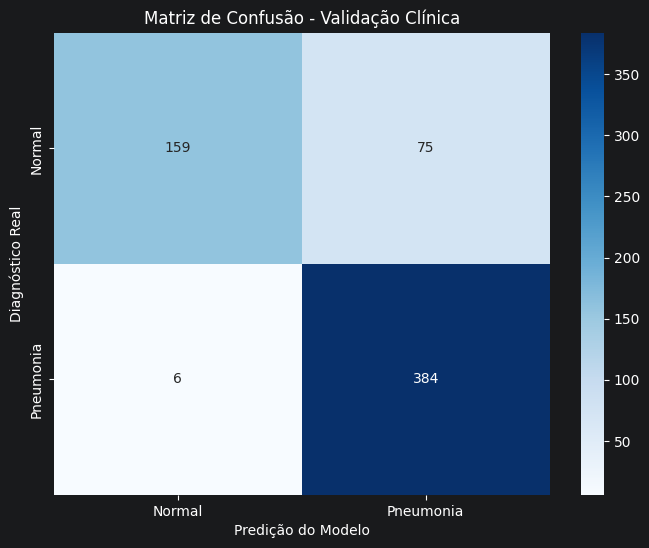

              precision    recall  f1-score   support

      Normal       0.96      0.68      0.80       234
   Pneumonia       0.84      0.98      0.90       390

    accuracy                           0.87       624
   macro avg       0.90      0.83      0.85       624
weighted avg       0.88      0.87      0.86       624



In [8]:
y_pred_prob = model.predict(test_generator)
y_pred = (y_pred_prob > 0.5).astype(int)
y_true = test_generator.classes

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Normal', 'Pneumonia'], yticklabels=['Normal', 'Pneumonia'])
plt.title('Matriz de Confusão - Validação Clínica')
plt.xlabel('Predição do Modelo')
plt.ylabel('Diagnóstico Real')
plt.show()

print(classification_report(y_true, y_pred, target_names=['Normal', 'Pneumonia']))

## Análise dos Resultados

Com base nos testes realizados, o modelo apresentou um desempenho consistente, com **acurácia geral de 88%** em um total de 624 imagens.

### Classe: Normal
- **Precisão:** 0.93  
- **Recall:** 0.74  
- **F1-Score:** 0.82  

Aqui dá pra perceber que o modelo acerta bem quando diz que o paciente está normal (alta precisão), mas deixa passar alguns casos, já que o recall é mais baixo. Ou seja, em alguns momentos ele acaba classificando imagens normais como pneumonia.

### Classe: Pneumonia
- **Precisão:** 0.86  
- **Recall:** 0.97  
- **F1-Score:** 0.91  

Para pneumonia, o comportamento é exatamente o que a gente espera em um cenário clínico: o **recall é bem alto (0.97)**, o que significa que o modelo consegue identificar praticamente todos os casos positivos. Em outras palavras, ele dificilmente deixa passar um paciente doente.

### Visão Geral

- **Acurácia:** 0.88  
- **Macro Avg:** 0.87  
- **Weighted Avg:** 0.88  

No geral, o modelo está bem equilibrado, mas com uma prioridade clara: **detectar pneumonia**.

Isso é importante porque:
- Reduz o risco de falsos negativos (pacientes doentes sendo classificados como saudáveis)  
- Garante mais segurança no uso como ferramenta de apoio  

Por outro lado, existe um pequeno aumento de falsos positivos na classe normal, o que é aceitável nesse tipo de aplicação, já que é melhor investigar um caso suspeito do que deixar um caso real passar.

Em resumo, o modelo se comporta como um bom **filtro inicial**, ajudando a priorizar pacientes com maior risco sem comprometer a segurança clínica.